In [1]:
import pandas as pd
df=pd.read_csv('./content/data.csv')

In [2]:
df.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97


In [10]:
df.describe()

,Order Quantity
count,4999.000000
mean,26.483097
std,14.391863
min,1.000000
25%,13.000000
50%,27.000000
75%,39.000000
max,50.000000


In [11]:
df.info

<bound method DataFrame.info of      Order No  Order Date           Customer Name  \
0      4293-1  02-09-2014        Vivek Sundaresam   
1      5001-1  24-10-2015          Shahid Hopkins   
2      5004-1  13-03-2014           Dennis Pardue   
3      5009-1  18-02-2013              Sean Wendt   
4      5010-1  13-09-2014  Christina Vanderzanden   
...       ...         ...                     ...   
4995   6831-1  02-11-2016           Roland Murray   
4996   6847-1  16-12-2015          Patrick OBrill   
4997   6922-1  28-09-2016            Troy Staebel   
4998   6939-1  18-06-2016             Shaun Weien   
4999   6980-1  12-08-2015          Nora Pelletier   

                                  Address       City State   Customer Type  \
0          152 Bunnerong Road,Eastgardens     Sydney   NSW  Small Business   
1           438 Victoria Avenue,Chatswood     Sydney   NSW       Corporate   
2                412 Brunswick St,Fitzroy  Melbourne   VIC        Consumer   
3                14

In [ ]:
df.isnull().sum()

,0
Order No,0
Order Date,0
Customer Name,0
Address,1
City,0
State,0
Customer Type,0
Account Manager,0
Order Priority,0
Product Name,0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   str    
 1   Order Date         5000 non-null   str    
 2   Customer Name      5000 non-null   str    
 3   Address            4999 non-null   str    
 4   City               5000 non-null   str    
 5   State              5000 non-null   str    
 6   Customer Type      5000 non-null   str    
 7   Account Manager    5000 non-null   str    
 8   Order Priority     5000 non-null   str    
 9   Product Name       5000 non-null   str    
 10  Product Category   5000 non-null   str    
 11  Product Container  5000 non-null   str    
 12  Ship Mode          5000 non-null   str    
 13  Ship Date          5000 non-null   str    
 14  Cost Price         5000 non-null   str    
 15  Retail Price       5000 non-null   str    
 16  Profit Margin      5000 non-null   

In [13]:
df.shape

(5000, 24)

In [14]:
df.dropna(subset=['Address', 'Order Quantity'], inplace=True)
print(f"DataFrame shape after dropping missing values: {df.shape}")

DataFrame shape after dropping missing values: (4998, 24)


In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

def clean_currency(value):
    if isinstance(value, str):
        return float(value.replace('$', '').replace(',', ''))
    return value

def clean_percentage(value):
    if isinstance(value, str):
        return float(value.replace('%', ''))
    return value

monetary_columns = ['Cost Price', 'Retail Price', 'Profit Margin', 'Sub Total', 'Discount $', 'Order Total', 'Shipping Cost', 'Total']
for col in monetary_columns:
    df[col] = df[col].apply(clean_currency)

df['Discount %'] = df['Discount %'].apply(clean_percentage)

print("Converted 'Order Date' and 'Ship Date' to datetime objects and cleaned monetary and percentage columns.")

Converted 'Order Date' and 'Ship Date' to datetime objects and cleaned monetary and percentage columns.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order No           4998 non-null   object        
 1   Order Date         4998 non-null   datetime64[ns]
 2   Customer Name      4998 non-null   object        
 3   Address            4998 non-null   object        
 4   City               4998 non-null   object        
 5   State              4998 non-null   object        
 6   Customer Type      4998 non-null   object        
 7   Account Manager    4998 non-null   object        
 8   Order Priority     4998 non-null   object        
 9   Product Name       4998 non-null   object        
 10  Product Category   4998 non-null   object        
 11  Product Container  4998 non-null   object        
 12  Ship Mode          4998 non-null   object        
 13  Ship Date          4998 non-null   datetime64[ns]
 14  Cost Price   

In [ ]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
monthly_sales_trend = df.groupby(['Order Year', 'Order Month'])['Total'].sum().reset_index()

print("Monthly sales trend calculated and stored in 'monthly_sales_trend'.")
print(monthly_sales_trend.head())

Monthly sales trend calculated and stored in 'monthly_sales_trend'.
   Order Year  Order Month      Total
0        2013            2   31874.37
1        2013            3   34953.17
2        2013            4   15468.78
3        2013            5  108712.11
4        2013            6  108847.89


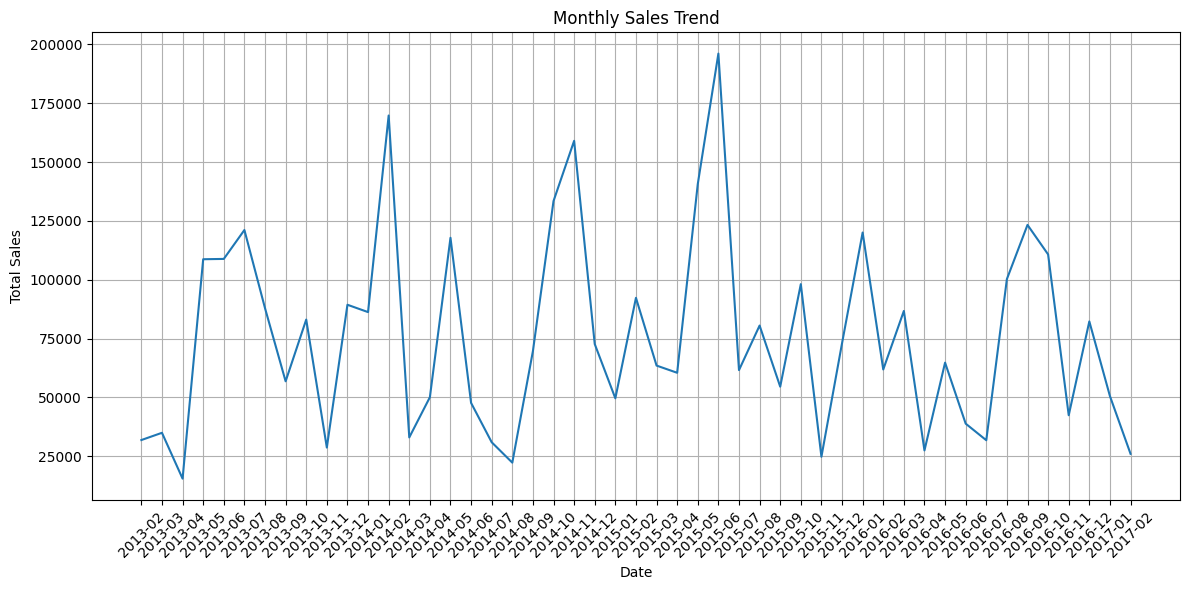

Monthly sales trend plot displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales_trend['YearMonth'] = monthly_sales_trend['Order Year'].astype(str) + '-' + monthly_sales_trend['Order Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales_trend, x='YearMonth', y='Total')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
print("Monthly sales trend plot displayed.")

In [ ]:
average_monthly_sales = df.groupby('Order Month')['Total'].sum().reset_index()
yearly_sales_trend = df.groupby('Order Year')['Total'].sum().reset_index()

print("Average monthly sales across all years:")
print(average_monthly_sales.head())
print("\nYearly sales trend:")
print(yearly_sales_trend.head())

Average monthly sales across all years:
   Order Month      Total
0            1  306471.96
1            2  381861.18
2            3  218192.94
3            4  153442.19
4            5  431974.59

Yearly sales trend:
   Order Year      Total
0        2013  766873.10
1        2014  992586.20
2        2015  995253.41
3        2016  890547.37
4        2017   76572.55


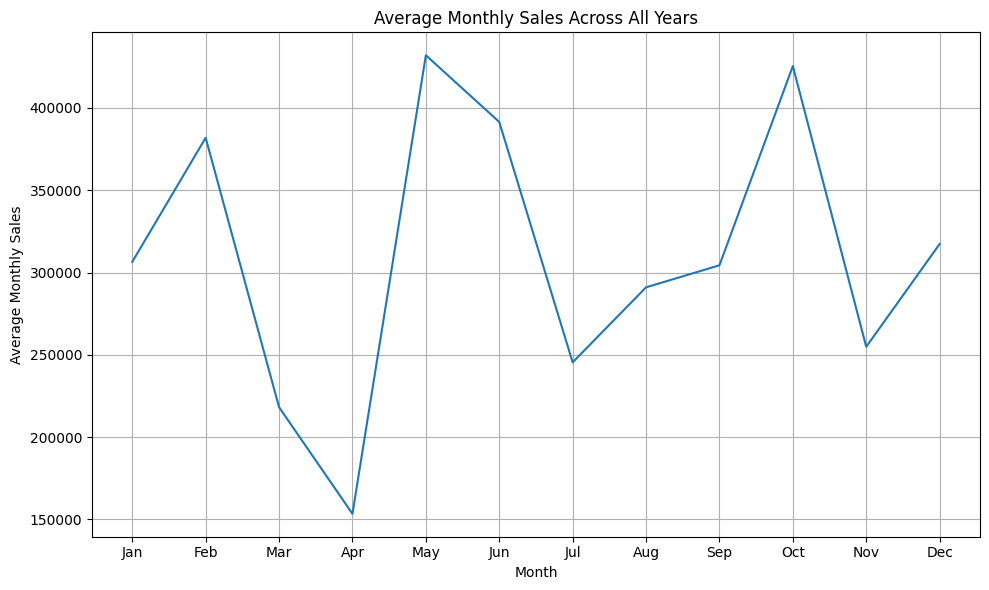

Average monthly sales trend plot displayed.


In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=average_monthly_sales, x='Order Month', y='Total')
plt.title('Average Monthly Sales Across All Years')
plt.xlabel('Month')
plt.ylabel('Average Monthly Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()
print("Average monthly sales trend plot displayed.")

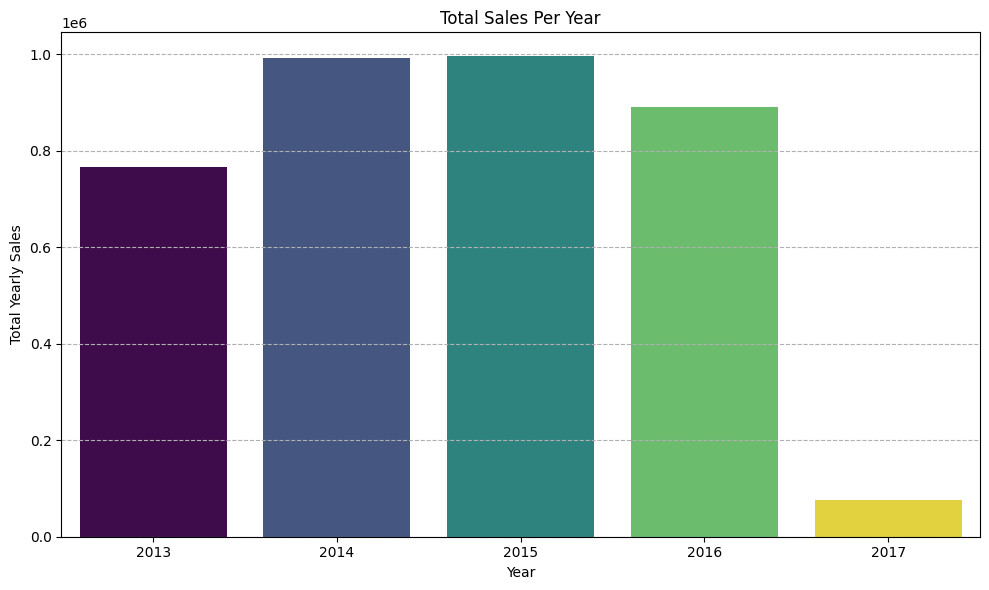

Yearly sales trend bar plot displayed.


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=yearly_sales_trend, x='Order Year', y='Total', hue='Order Year', legend=False, palette='viridis')
plt.title('Total Sales Per Year')
plt.xlabel('Year')
plt.ylabel('Total Yearly Sales')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()
print("Yearly sales trend bar plot displayed.")

In [ ]:
train_data = monthly_sales_trend[monthly_sales_trend['Order Year'] <= 2015]
test_data = monthly_sales_trend[monthly_sales_trend['Order Year'] > 2015]

print(f"Shape of training data: {train_data.shape}")
print(f"Shape of testing data: {test_data.shape}")

Shape of training data: (35, 4)
Shape of testing data: (14, 4)


In [ ]:
import statsmodels.api as sm
train_series = train_data['Total']

model = sm.tsa.SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(0, 1, 0, 12))

sarima_model_fit = model.fit(disp=False)

print("SARIMA model fitted successfully with further simplified seasonal order.")

SARIMA model fitted successfully with further simplified seasonal order.


In [ ]:
forecast_steps = len(test_data)
forecast = sarima_model_fit.get_forecast(steps=forecast_steps)

# Extract predicted values and confidence intervals
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

print("Forecast generated successfully for the test data period.")
print("Predicted means:")
print(forecast_mean.head())

Forecast generated successfully for the test data period.
Predicted means:
35     -5306.725581
36     78739.941660
37     19003.164986
38     39099.116178
39    101977.525610
Name: predicted_mean, dtype: float64


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Align the index of forecast_mean with test_data['Total'] for accurate comparison
forecast_mean.index = test_data['Total'].index

mae = mean_absolute_error(test_data['Total'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test_data['Total'], forecast_mean))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Absolute Error (MAE): 56291.22
Root Mean Squared Error (RMSE): 68808.40


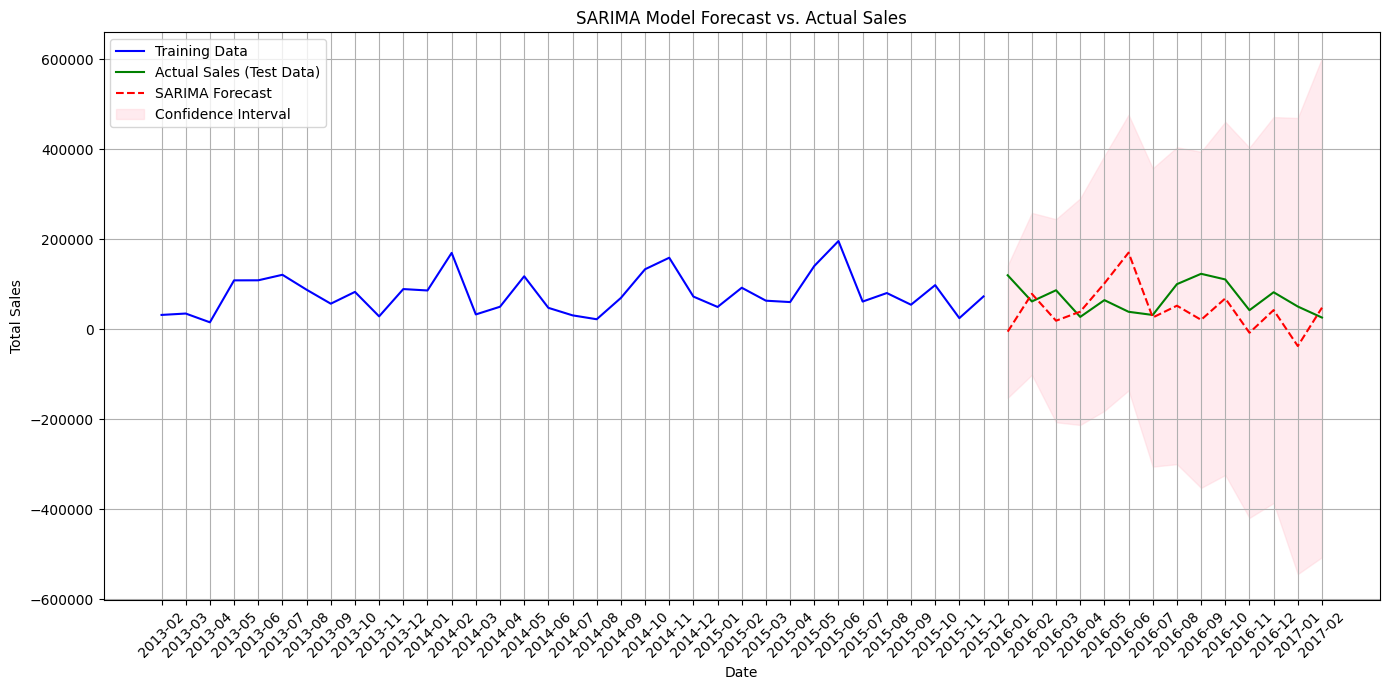

SARIMA model forecast plot displayed.


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(train_data['YearMonth'], train_data['Total'], label='Training Data', color='blue')
plt.plot(test_data['YearMonth'], test_data['Total'], label='Actual Sales (Test Data)', color='green')
plt.plot(test_data['YearMonth'], forecast_mean, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(test_data['YearMonth'], conf_int['lower Total'], conf_int['upper Total'], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('SARIMA Model Forecast vs. Actual Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("SARIMA model forecast plot displayed.")

In [ ]:
def calculate_mape(y_true, y_pred):
    # Ensure y_true and y_pred are numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    non_zero_actuals_idx = y_true != 0
    y_true_filtered = y_true[non_zero_actuals_idx]
    y_pred_filtered = y_pred[non_zero_actuals_idx]

    if len(y_true_filtered) == 0:
        return np.nan # Cannot compute MAPE if all actuals are zero or filtered out

    mape = np.mean(np.abs((y_true_filtered - y_pred_filtered) / y_true_filtered)) * 100
    return mape

# Calculate MAPE
mape_value = calculate_mape(test_data['Total'], forecast_mean)

print(f"Mean Absolute Percentage Error (MAPE): {mape_value:.2f}%")

Mean Absolute Percentage Error (MAPE): 89.98%


In [ ]:
import pickle

# Define the filename
filename = 'sarima_model.pkl'

# Save the model
with open(filename, 'wb') as file:
    pickle.dump(sarima_model_fit, file)

print(f"SARIMA model successfully saved to '{filename}'.")

SARIMA model successfully saved to 'sarima_model.pkl'.


In [3]:
# import joblib

# # Replace 'results' with whatever your SARIMA model variable name is
# joblib.dumpsarima_model.pkl')
# print("Model exported successfully for the Dashboard!")

## Explain SARIMA Components

### Subtask:
Provide a detailed explanation of each component of the SARIMA model: Seasonal (S), AutoRegressive (AR), Integrated (I), and Moving Average (MA), along with their respective parameters.
